In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
data1 = pd.read_csv("/content/fiat500.csv")

In [ ]:
data1 = pd.read_csv("/content/fiat500.csv")
data1.head(10)

,ID,model,engine_power,age_in_days,km,previous_owners,lat,lon,price
0,1,lounge,51,882,25000,1,44.907242,8.611560,8900
1,2,pop,51,1186,32500,1,45.666359,12.241890,8800
2,3,sport,74,4658,142228,1,45.503300,11.417840,4200
3,4,lounge,51,2739,160000,1,40.633171,17.634609,6000
4,5,pop,73,3074,106880,1,41.903221,12.495650,5700
5,6,pop,74,3623,70225,1,45.000702,7.682270,7900
6,7,lounge,51,731,11600,1,44.907242,8.611560,10750
7,8,lounge,51,1521,49076,1,41.903221,12.495650,9190
8,9,sport,73,4049,76000,1,45.548000,11.549470,5600
9,10,sport,51,3653,89000,1,45.438301,10.991700,6000


In [ ]:
data1.shape

(1520, 9)

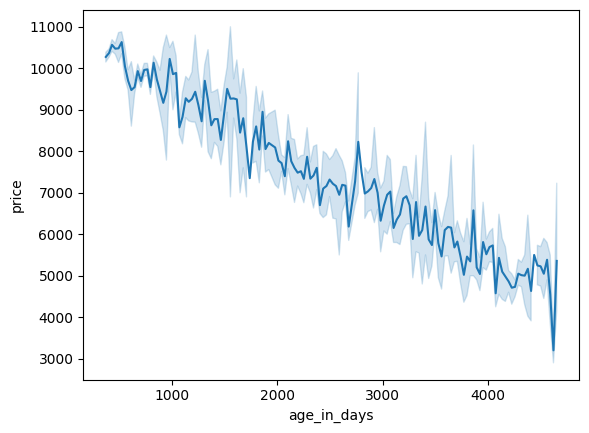

In [ ]:
sns.lineplot(x="age_in_days", y="price", data=data1)
plt.show()

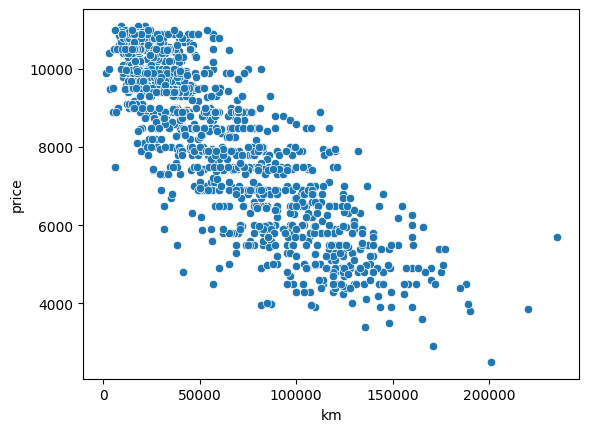

In [ ]:
sns.scatterplot(x="km", y="price", data=data1)
plt.show()

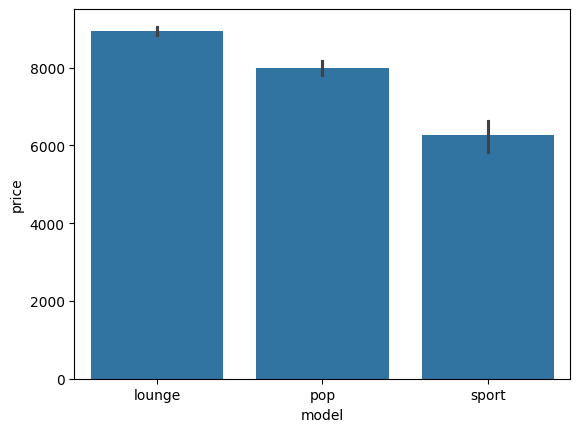

In [ ]:
sns.barplot(x="model", y="price", data=data1)
plt.show()

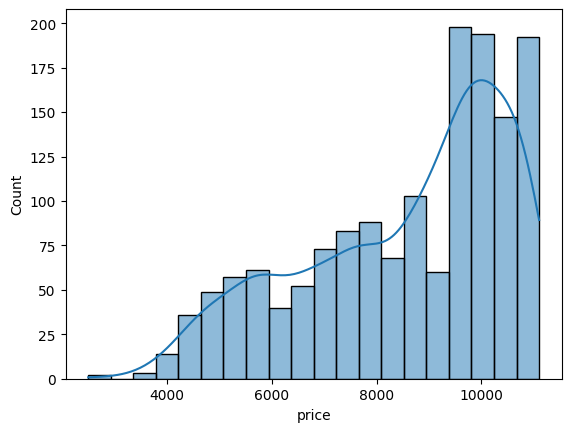

In [ ]:
sns.histplot(data1["price"], bins=20, kde=True)
plt.show()

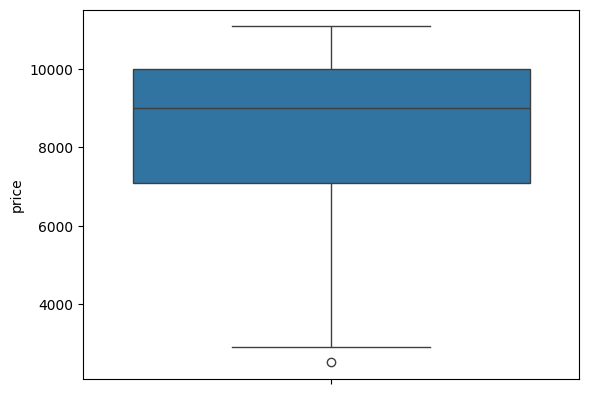

In [ ]:
sns.boxplot(y="price", data=data1)
plt.show()

In [ ]:
data2 = pd.get_dummies(data1, dtype=int)
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1520 entries, 0 to 1519
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               1520 non-null   int64  
 1   engine_power     1520 non-null   int64  
 2   age_in_days      1520 non-null   int64  
 3   km               1520 non-null   int64  
 4   previous_owners  1520 non-null   int64  
 5   lat              1520 non-null   float64
 6   lon              1520 non-null   float64
 7   price            1520 non-null   int64  
 8   model_lounge     1520 non-null   int64  
 9   model_pop        1520 non-null   int64  
 10  model_sport      1520 non-null   int64  
dtypes: float64(2), int64(9)
memory usage: 130.8 KB


In [ ]:
data2.corr()

,ID,engine_power,age_in_days,km,previous_owners,lat,lon,price,model_lounge,model_pop,model_sport
ID,1.000000,-0.033980,-0.058918,-0.005935,0.003170,-0.064312,0.065560,0.027365,0.020680,-0.006226,-0.029370
engine_power,-0.033980,1.000000,0.319740,0.285135,-0.005149,0.005945,-0.005850,-0.277180,-0.133224,0.024107,0.218700
age_in_days,-0.058918,0.319740,1.000000,0.835261,0.072589,0.064866,-0.044418,-0.893488,-0.260046,0.108815,0.313059
km,-0.005935,0.285135,0.835261,1.000000,0.095087,0.037562,0.002778,-0.860361,-0.254904,0.108495,0.303491
previous_owners,0.003170,-0.005149,0.072589,0.095087,1.000000,0.000180,-0.023382,-0.074107,-0.019021,-0.018800,0.072221
lat,-0.064312,0.005945,0.064866,0.037562,0.000180,1.000000,-0.765797,-0.013393,-0.043850,0.031615,0.028336
lon,0.065560,-0.005850,-0.044418,0.002778,-0.023382,-0.765797,1.000000,-0.001792,0.011693,-0.007161,-0.009897
price,0.027365,-0.277180,-0.893488,-0.860361,-0.074107,-0.013393,-0.001792,1.000000,0.301936,-0.166712,-0.289083
model_lounge,0.020680,-0.133224,-0.260046,-0.254904,-0.019021,-0.043850,0.011693,0.301936,1.000000,-0.865047,-0.380693
model_pop,-0.006226,0.024107,0.108815,0.108495,-0.018800,0.031615,-0.007161,-0.166712,-0.865047,1.000000,-0.134596


In [ ]:
print(data1.columns.tolist())

['ID', 'model', 'engine_power', 'age_in_days', 'km', 'previous_owners', 'lat', 'lon', 'price']


In [ ]:
data1 = data1.drop("ID", axis=1)

In [ ]:
X = data1.drop(["price"], axis=1)
y = data1["price"]

print(X.head())


    model  engine_power  age_in_days      km  previous_owners        lat  \
0  lounge            51          882   25000                1  44.907242   
1     pop            51         1186   32500                1  45.666359   
2   sport            74         4658  142228                1  45.503300   
3  lounge            51         2739  160000                1  40.633171   
4     pop            73         3074  106880                1  41.903221   

         lon  
0   8.611560  
1  12.241890  
2  11.417840  
3  17.634609  
4  12.495650  


In [ ]:
print(y.head())

0    8900
1    8800
2    4200
3    6000
4    5700
Name: price, dtype: int64


In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1216, 7)
(304, 7)
(1216,)
(304,)


In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

data1 = pd.read_csv("/content/fiat500.csv")
data2 = pd.get_dummies(data1, dtype=int)

X = data2.drop(['ID', 'lat','lon'], axis=1)
y = data2['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print(y_pred[:5])
print(y_test[:5])

[ 9980.  9600.  6800.  9890. 10500.]
461      9980
1314     9600
1472     6800
744      9890
247     10500
Name: price, dtype: int64


In [ ]:
import pandas as pd

result = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print(result.head(10))

      Actual  Predicted
461     9980     9980.0
1314    9600     9600.0
1472    6800     6800.0
744     9890     9890.0
247    10500    10500.0
430     7950     7950.0
939     9490     9490.0
1490    9950     9950.0
358     8579     8579.0
427     9450     9450.0


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 7.381566702909032e-11
MSE: 8.287378344759359e-21
R2 Score: 1.0


In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("R2:", r2_score(y_test, y_pred))

R2: 0.999638105203689


In [ ]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_ # Changed coef_ to feature_importances_
})

print(coefficients.sort_values(by="Importance", ascending=False))

           Feature  Importance
1      age_in_days    0.795384
2               km    0.129970
4              lat    0.030640
5              lon    0.027127
7        model_pop    0.006625
6     model_lounge    0.004078
3  previous_owners    0.002199
0     engine_power    0.002040
8      model_sport    0.001937


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Ensure data1 is loaded for this block, consistent with its state when data2 was first created
data1 = pd.read_csv("/content/fiat500.csv")

# Re-create data2, X, y, X_train, X_test, y_train, y_test
data2 = pd.get_dummies(data1, dtype=int) # data2 will now have the 'ID' column
X = data2.drop(['ID', 'price'], axis=1) # Drop 'ID' and 'price' from data2 to get X
y = data2['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Re-train RandomForestRegressor and get y_pred
model = RandomForestRegressor()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

FileNotFoundError: [Errno 2] No such file or directory: '/content/fiat500.csv'

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(y_test.values, label="Actual Price")
plt.plot(y_pred, label="Predicted Price")

plt.title("Actual vs Predicted Car Prices")
plt.xlabel("Test Samples")
plt.ylabel("Price")
plt.legend()

plt.show()

NameError: name 'y_test' is not defined

<Figure size 1000x500 with 0 Axes>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Ensure data1 and data2 are defined
data1 = pd.read_csv("/content/fiat500.csv")
data2 = pd.get_dummies(data1, dtype=int)

X = data2.drop(["price", "ID"], axis=1)
y = data2["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

NameError: name 'data2' is not defined

In [ ]:
import pandas as pd

data = pd.read_csv("/content/fiat500.csv")

data = pd.get_dummies(data, columns=["model"], drop_first=True)

print(data.head())

   ID  engine_power  age_in_days      km  previous_owners        lat  \
0   1            51          882   25000                1  44.907242   
1   2            51         1186   32500                1  45.666359   
2   3            74         4658  142228                1  45.503300   
3   4            51         2739  160000                1  40.633171   
4   5            73         3074  106880                1  41.903221   

         lon  price  model_pop  model_sport  
0   8.611560   8900      False        False  
1  12.241890   8800       True        False  
2  11.417840   4200      False         True  
3  17.634609   6000      False        False  
4  12.495650   5700       True        False  


In [ ]:
from sklearn.model_selection import train_test_split

X = data.drop(["price", "ID"], axis=1)
y = data["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error

print("R² Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R² Score: 0.8319585894022132
MAE: 617.9010005536362


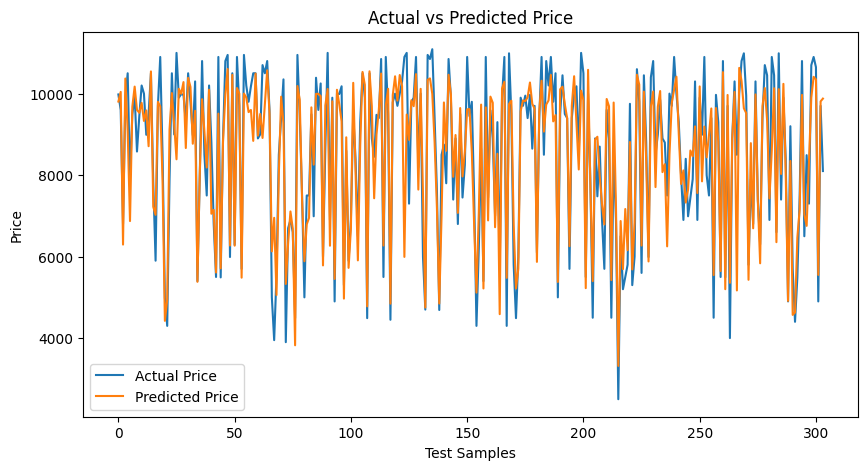

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual Price")
plt.plot(y_pred, label="Predicted Price")
plt.title("Actual vs Predicted Price")
plt.xlabel("Test Samples")
plt.ylabel("Price")
plt.legend()
plt.show()

In [ ]:
print(data.columns)

Index(['ID', 'engine_power', 'age_in_days', 'km', 'previous_owners', 'lat',
       'lon', 'price', 'model_pop', 'model_sport'],
      dtype='object')


In [ ]:
from sklearn.linear_model import Ridge

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge

# Load the data
data = pd.read_csv("/content/fiat500.csv")

# Apply one-hot encoding for the 'model' column
data = pd.get_dummies(data, columns=["model"], drop_first=True)

# Define features (X) and target (y)
X = data.drop(["price", "ID"], axis=1)
y = data["price"]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize and fit the Ridge model
model = Ridge(alpha=1.0)
model.fit(X_train, y_train)

Ridge()

In [ ]:
from sklearn.linear_model import GridSearchCV

ImportError: cannot import name 'GridSearchCV' from 'sklearn.linear_model' (/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/__init__.py)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

# Define the parameter grid for alpha values
param_grid = {'alpha': [0.1, 1.0, 10.0, 100.0]}

# Initialize Ridge regression model
ridge_model = Ridge()

# Initialize GridSearchCV
ridge_grid_search = GridSearchCV(ridge_model, param_grid, cv=5, scoring='neg_mean_squared_error')

# Fit GridSearchCV to the training data
ridge_grid_search.fit(X_train, y_train)

# Print the best parameters found
print(ridge_grid_search.best_params_)

{'alpha': 10.0}


In [ ]:
ridge=Ridge(alpha=10)
ridge.fit(X_train,y_train)
y_pred=ridge.predict(X_test)

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error

print("R² Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))


R² Score: 0.8319994975743049
MAE: 618.2040612443993


In [ ]:
from sklearn.metrics import mean_squared_error
print("MSE:", mean_squared_error(y_test, y_pred))

MSE: 681043.5994369066


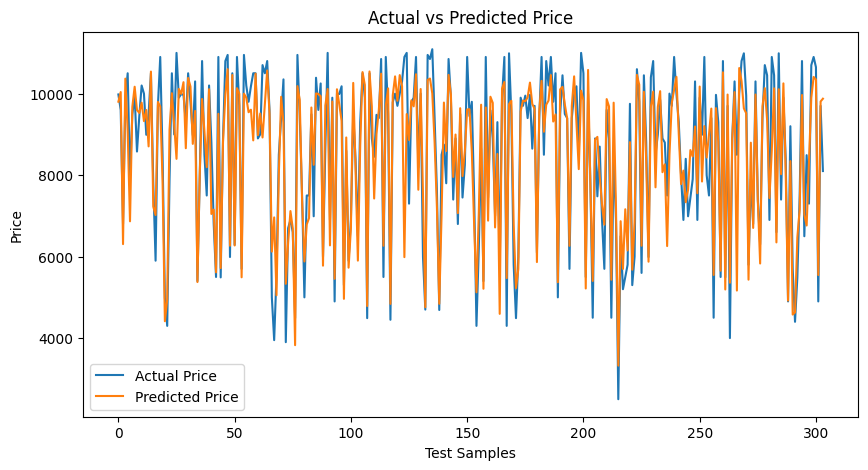

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual Price")
plt.plot(y_pred, label="Predicted Price")
plt.title("Actual vs Predicted Price")
plt.xlabel("Test Samples")
plt.ylabel("Price")
plt.legend()
plt.show()